In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('salaires.csv')

In [3]:
df

,Name,Age,Salary
0,Ines,29,4900
1,Omar,32,5300
2,Sabrina,40,6500
3,Souad,41,6300
4,Nezha,43,6400
5,Rabia,39,8000
6,Soufiane,41,8200
7,Abdellah,39,5800
8,Mohamed,27,7000
9,Yassine,29,9000


Text(0, 0.5, 'Salary')

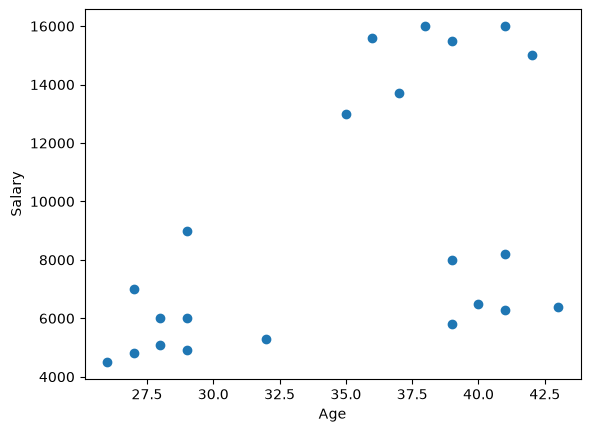

In [4]:
plt.scatter(df['Age'], df['Salary'])
plt.xlabel("Age")
plt.ylabel("Salary")

In [5]:
# k means clustering
km = KMeans(n_clusters=3, random_state=0)
X = df.drop(columns=['Name'])
km.fit(X)
km.labels_

array([1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
      dtype=int32)

In [6]:
predicted = km.predict(X)
predicted


array([1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
      dtype=int32)

In [7]:
km.labels_==predicted

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [8]:
df['cluster']= predicted
df

,Name,Age,Salary,cluster
0,Ines,29,4900,1
1,Omar,32,5300,1
2,Sabrina,40,6500,1
3,Souad,41,6300,1
4,Nezha,43,6400,1
5,Rabia,39,8000,2
6,Soufiane,41,8200,2
7,Abdellah,39,5800,1
8,Mohamed,27,7000,2
9,Yassine,29,9000,2


In [9]:
cluster1 = df[df['cluster']==0]
cluster2 = df[df['cluster']==1]
cluster3 = df[df['cluster']==2]

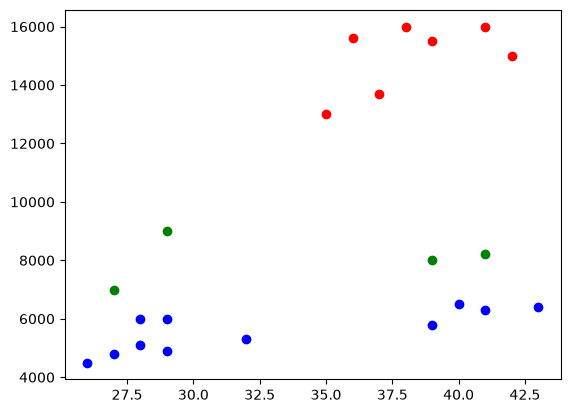

In [10]:
plt.scatter(cluster1['Age'], cluster1['Salary'], color='red')
plt.scatter(cluster2['Age'], cluster2['Salary'], color='blue')
plt.scatter(cluster3['Age'], cluster3['Salary'], color='green')

In [11]:
import seaborn as sns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,22.0,34.818182,5.901060,26.0,29.0,36.5,39.75,43.0
Salary,22.0,9027.272727,4340.636536,4500.0,5850.0,6750.0,13525.00,16000.0
cluster,22.0,0.863636,0.710161,0.0,0.0,1.0,1.00,2.0


<Axes: xlabel='Age'>

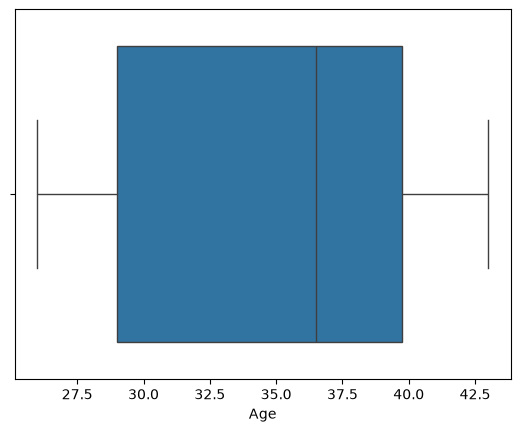

In [12]:
sns.boxplot(x=df['Age'])

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

In [14]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled

array([[0.17647059, 0.03478261],
       [0.35294118, 0.06956522],
       [0.82352941, 0.17391304],
       [0.88235294, 0.15652174],
       [1.        , 0.16521739],
       [0.76470588, 0.30434783],
       [0.88235294, 0.32173913],
       [0.76470588, 0.11304348],
       [0.05882353, 0.2173913 ],
       [0.17647059, 0.39130435],
       [0.70588235, 1.        ],
       [0.58823529, 0.96521739],
       [0.52941176, 0.73913043],
       [0.64705882, 0.8       ],
       [0.        , 0.        ],
       [0.05882353, 0.02608696],
       [0.11764706, 0.05217391],
       [0.17647059, 0.13043478],
       [0.11764706, 0.13043478],
       [0.94117647, 0.91304348],
       [0.76470588, 0.95652174],
       [0.88235294, 1.        ]])

In [16]:
scaler.inverse_transform([[0.88235294, 1.       ]])

array([[   40.99999998, 16000.        ]])

In [17]:
estimator = Pipeline([
    ("MinMaxScaler", MinMaxScaler()),
    ("clustering", KMeans(n_clusters=3, random_state=0))
]
)

In [18]:
estimator.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('MinMaxScaler', ...), ('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['Age','Salary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value


In [19]:
predicted2 = estimator.predict(X)
df['cluster2'] = predicted2

cluster1 = df[df['cluster2']==0]
cluster2 = df[df['cluster2']==1]
cluster3 = df[df['cluster2']==2]

In [20]:
centers_scaled = estimator[-1].cluster_centers_
centers = estimator[0].inverse_transform(centers_scaled)

centers_scaled

array([[0.72268908, 0.91055901],
       [0.1372549 , 0.11690821],
       [0.85294118, 0.2057971 ]])

In [21]:
centers

array([[   38.28571429, 14971.42857143],
       [   28.33333333,  5844.44444444],
       [   40.5       ,  6866.66666667]])

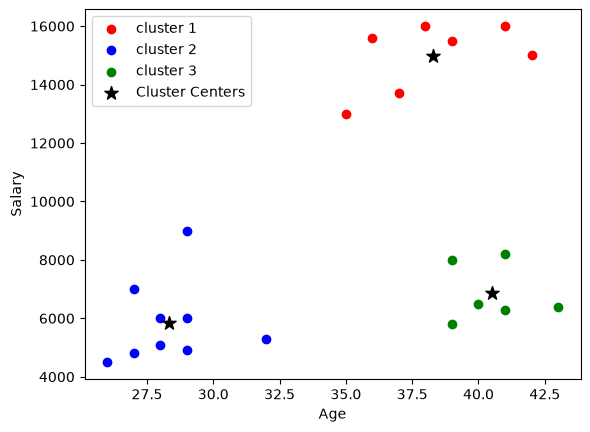

In [22]:
plt.scatter(cluster1['Age'], cluster1['Salary'], color='red', label = "cluster 1")
plt.scatter(cluster2['Age'], cluster2['Salary'], color='blue', label = "cluster 2")
plt.scatter(cluster3['Age'], cluster3['Salary'], color='green', label = "cluster 3")
plt.scatter(centers[:,0], centers[:,1], color="black", marker='*', s=100, label="Cluster Centers")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.legend()

In [23]:
# elbow and silhouette methods to find the optimal number of clusters
from sklearn.metrics import silhouette_score
sse=[]
sil=[]
krange = range(1,10)
for k in krange:
    km = Pipeline([
        ("MinMaxScaler", MinMaxScaler()),
        ("clustering", KMeans(n_clusters=k, random_state=0))
        ]
        )
    km.fit(X)
    sse.append(km[-1].inertia_)
    if(k==1):
        sil.append(0)
    else :    
        sil.append(silhouette_score(X, km[-1].labels_))

In [24]:
sse

[5.522140987850921,
 2.139183706762151,
 0.4796830920366221,
 0.3546287126734011,
 0.26819371493732613,
 0.22690756427112166,
 0.18904083568265523,
 0.18057431161055554,
 0.14689918738539565]

In [25]:
sil

[0,
 0.25657476200964113,
 0.35398455359639963,
 0.1995366438963641,
 0.19160118123962888,
 0.0694716270838743,
 -0.020201042966170576,
 0.1380407992851944,
 0.2576952732350539]

Text(0, 0.5, 'SSE')

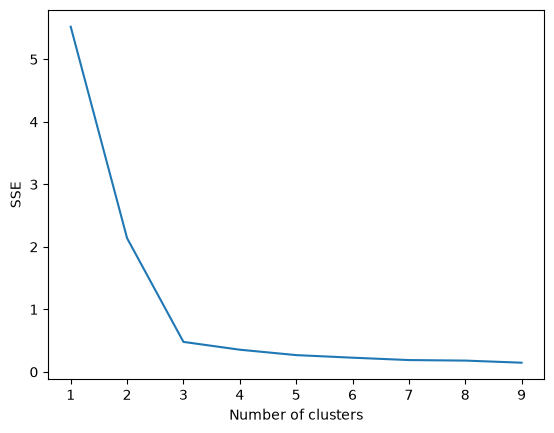

In [26]:
plt.plot(krange, sse,)
plt.xlabel("Number of clusters")
plt.ylabel("SSE")

Text(0, 0.5, 'Silhouette')

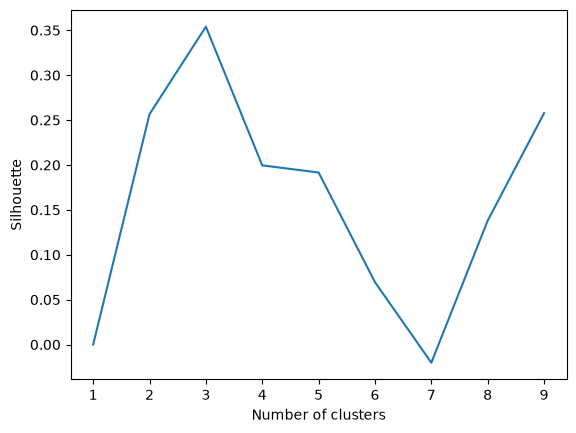

In [27]:
plt.plot(krange, sil,)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette")

In [28]:
from sklearn.datasets import load_digits
import pandas as pd

In [29]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [30]:
data = dataset.data
data.shape

(1797, 64)

In [31]:
data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [32]:
data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

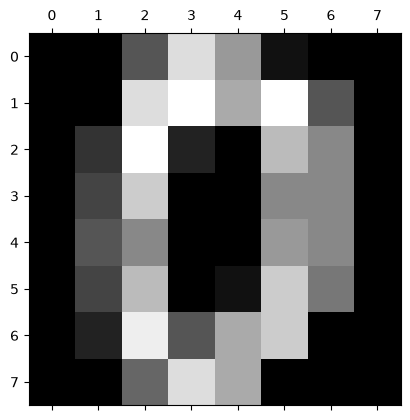

In [33]:
from matplotlib import pyplot as plt
plt.gray()
plt.matshow(dataset.data[0].reshape(8,8))

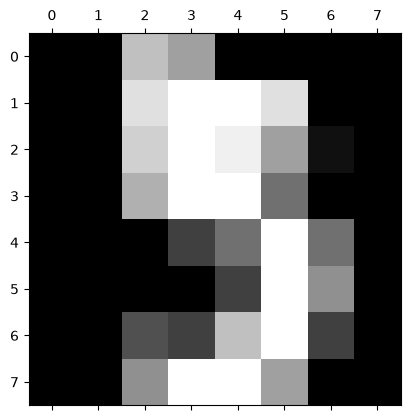

In [34]:
plt.matshow(dataset.data[5].reshape(8,8))

In [35]:
dataset.target[:20]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [36]:
df = pd.DataFrame(data=data, columns=dataset['feature_names'])
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [37]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [38]:
# logistic regression
X = df
y = dataset.target

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=30)

In [42]:
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9722222222222222

In [43]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [44]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       0.99      1.00      1.00       136
           2       1.00      1.00      1.00       136
           3       1.00      1.00      1.00       157
           4       1.00      1.00      1.00       146
           5       1.00      1.00      1.00       144
           6       1.00      1.00      1.00       139
           7       1.00      1.00      1.00       147
           8       1.00      0.99      1.00       139
           9       1.00      1.00      1.00       150

    accuracy                           1.00      1437
   macro avg       1.00      1.00      1.00      1437
weighted avg       1.00      1.00      1.00      1437



In [45]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      0.93      0.97        46
           2       0.98      1.00      0.99        41
           3       0.93      0.96      0.94        26
           4       1.00      0.94      0.97        35
           5       1.00      0.95      0.97        38
           6       1.00      1.00      1.00        42
           7       1.00      1.00      1.00        32
           8       0.94      0.97      0.96        35
           9       0.85      0.97      0.91        30

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



[[143   0   0   0   0   0   0   0   0   0]
 [  0 136   0   0   0   0   0   0   0   0]
 [  0   0 136   0   0   0   0   0   0   0]
 [  0   0   0 157   0   0   0   0   0   0]
 [  0   0   0   0 146   0   0   0   0   0]
 [  0   0   0   0   0 144   0   0   0   0]
 [  0   0   0   0   0   0 139   0   0   0]
 [  0   0   0   0   0   0   0 147   0   0]
 [  0   1   0   0   0   0   0   0 138   0]
 [  0   0   0   0   0   0   0   0   0 150]]


<Axes: >

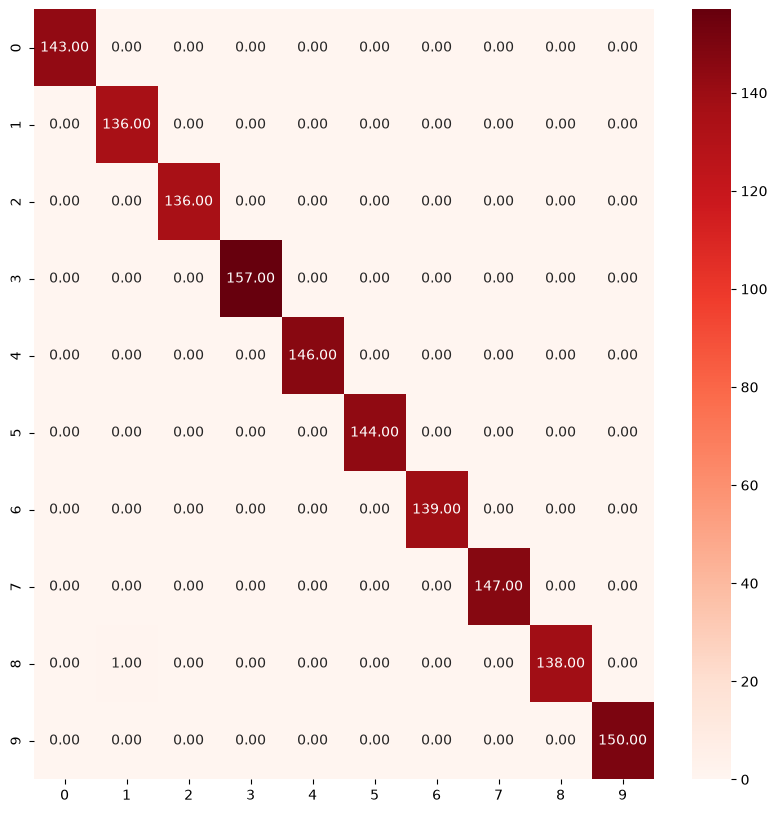

In [46]:
cm_train = confusion_matrix(y_train, pred_train)
print(cm_train)
plt.figure(figsize=(10,10))
sns.heatmap(cm_train, annot=True, fmt='.2f', cmap='Reds')

[[35  0  0  0  0  0  0  0  0  0]
 [ 0 43  0  0  0  0  0  0  2  1]
 [ 0  0 41  0  0  0  0  0  0  0]
 [ 0  0  1 25  0  0  0  0  0  0]
 [ 0  0  0  0 33  0  0  0  0  2]
 [ 0  0  0  0  0 36  0  0  0  2]
 [ 0  0  0  0  0  0 42  0  0  0]
 [ 0  0  0  0  0  0  0 32  0  0]
 [ 0  0  0  1  0  0  0  0 34  0]
 [ 0  0  0  1  0  0  0  0  0 29]]


<Axes: >

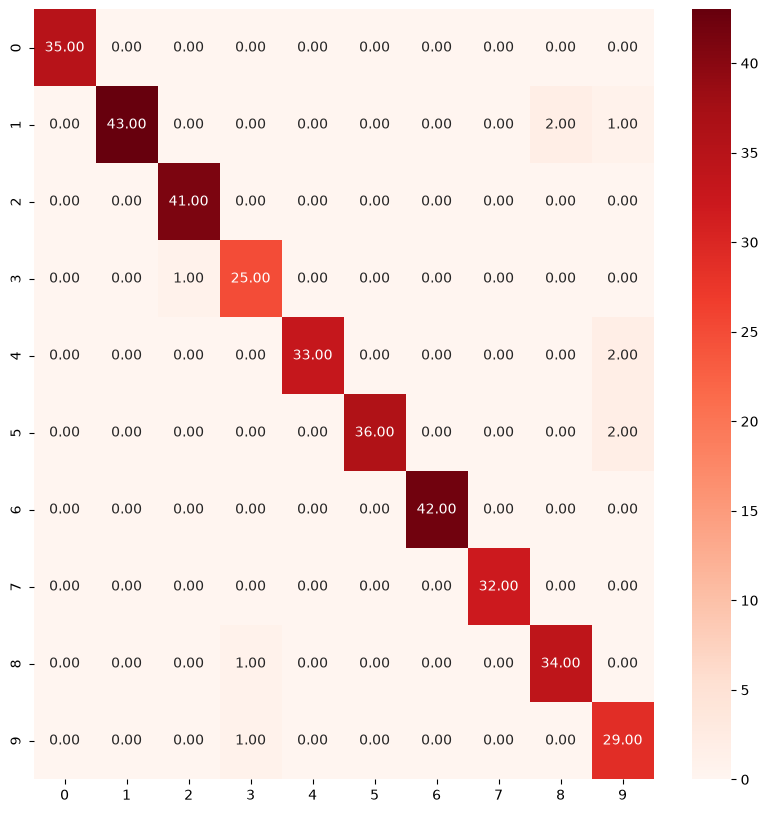

In [47]:
cm_test = confusion_matrix(y_test, pred_test)
print(cm_test)
plt.figure(figsize=(10,10))
sns.heatmap(cm_test, annot=True, fmt='.2f', cmap='Reds')

In [48]:
#pca 
pca = PCA(0.95)
X_pca = pca.fit_transform(X)
X_pca.shape

(1797, 29)

In [49]:
evr=pca.explained_variance_ratio_
evr

array([0.14890594, 0.13618771, 0.11794594, 0.08409979, 0.05782415,
       0.0491691 , 0.04315987, 0.03661373, 0.03353248, 0.03078806,
       0.02372341, 0.02272697, 0.01821863, 0.01773855, 0.01467101,
       0.01409716, 0.01318589, 0.01248138, 0.01017718, 0.00905617,
       0.00889538, 0.00797123, 0.00767493, 0.00722904, 0.00695889,
       0.00596081, 0.00575615, 0.00515158, 0.0048954 ])

In [50]:
evr.sum()

np.float64(0.9547965245651596)

In [51]:
pca.n_components_

np.int64(29)

In [52]:
X_pca

array([[ -1.25946645, -21.27488348,   9.46305462, ...,   3.67072108,
          0.9436689 ,   1.13250195],
       [  7.9576113 ,  20.76869896,  -4.43950604, ...,   2.18261819,
          0.51022719,  -2.31354911],
       [  6.99192297,   9.95598641,  -2.95855808, ...,   4.22882114,
         -2.1576573 ,  -0.8379578 ],
       ...,
       [ 10.8012837 ,   6.96025223,  -5.59955453, ...,  -3.56866194,
         -1.82444444,  -3.53885886],
       [ -4.87210009, -12.42395362,  10.17086635, ...,   3.25330054,
         -0.95484174,   0.93895602],
       [ -0.34438963,  -6.36554919, -10.77370849, ...,  -3.01636722,
         -1.29752723,  -2.58810313]], shape=(1797, 29))

In [53]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=30)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)
model.score(X_test_pca, y_test)

0.9694444444444444

In [54]:
# pca 2 components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)
X_pca2.shape

(1797, 2)

In [55]:
X_pca2

array([[ -1.25946645, -21.27488348],
       [  7.9576113 ,  20.76869896],
       [  6.99192297,   9.95598641],
       ...,
       [ 10.8012837 ,   6.96025223],
       [ -4.87210009, -12.42395362],
       [ -0.34438963,  -6.36554919]], shape=(1797, 2))

In [56]:
pca2.explained_variance_ratio_

array([0.14890594, 0.13618771])

In [57]:
pca2.explained_variance_ratio_.sum()

np.float64(0.28509364823699296)

In [58]:
X_train_pca2, X_test_pca2, y_train2, y_test2 = train_test_split(X_pca2, y, test_size=0.2, random_state=30)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca2, y_train2)
model.score(X_test_pca2, y_test2)

0.6083333333333333